<a href="https://colab.research.google.com/github/Priyahiremath97/Student_Placement_eligibility/blob/main/Student_Placement_eligibility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
     accuracy_score,
     precision_score,
     recall_score,
     f1_score,
     roc_auc_score,
     confusion_matrix,
     classification_report,
     ConfusionMatrixDisplay,
     roc_curve)




Load dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/dataset/dataset_07_student_placement_eligibility.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (1000, 7)

First 5 rows:
   cgpa  attendance_pct  coding_score  projects_completed  internship_months  \
0  8.18           76.43             4                   3                 14   
1  9.28           46.50             3                   3                 50   
2  7.61           30.59             6                   2                 25   
3  7.47           50.98             0                   4                 56   
4  6.17           25.42             2                   2                 55   

   backlogs  target  
0         4       1  
1         5       0  
2         2       1  
3         3       0  
4         4       1  


Inspect The Dataset

In [ ]:
print("Column Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Column Names:
Index(['cgpa', 'attendance_pct', 'coding_score', 'projects_completed',
       'internship_months', 'backlogs', 'target'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cgpa                1000 non-null   float64
 1   attendance_pct      1000 non-null   float64
 2   coding_score        1000 non-null   int64  
 3   projects_completed  1000 non-null   int64  
 4   internship_months   1000 non-null   int64  
 5   backlogs            1000 non-null   int64  
 6   target              1000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 54.8 KB
None

Statistical Summary:
              cgpa  attendance_pct  coding_score  projects_completed  \
count  1000.000000     1000.000000   1000.000000         1000.000000   
mean      7.262610       50.859510      2.999000    

Data quality values

In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
cgpa                  0
attendance_pct        0
coding_score          0
projects_completed    0
internship_months     0
backlogs              0
target                0
dtype: int64


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
print("Target distribution:")
print(df["target"].value_counts())

print("\nTarget percentage:")
print(df["target"].value_counts(normalize=True) * 100)

Target distribution:
target
1    500
0    500
Name: count, dtype: int64

Target percentage:
target
1    50.0
0    50.0
Name: proportion, dtype: float64


Visualize it

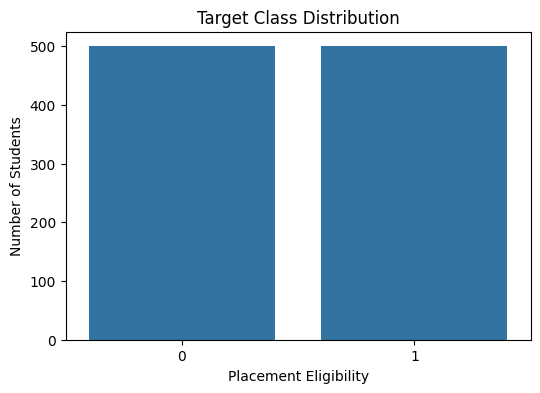

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Target Class Distribution")
plt.xlabel("Placement Eligibility")
plt.ylabel("Number of Students")
plt.show()

In [ ]:
for col in df.columns:
      print("\n", col)
      print(df[col].unique()[:20])


 cgpa
[ 8.18  9.28  7.61  7.47  6.17 10.    7.78  5.59  5.71  9.17  5.48  5.52
  9.19  8.76  5.86  7.69  6.67  7.32  6.21  7.65]

 attendance_pct
[76.43 46.5  30.59 50.98 25.42 47.37 35.22 47.2  49.68 54.16 59.66 79.73
 45.41 59.88 41.94 40.96 40.89 53.42 19.99 88.92]

 coding_score
[ 4  3  6  0  2  1  5  8  7  9 10]

 projects_completed
[3 2 4 7 1 6 5 0 8 9]

 internship_months
[14 50 25 56 55 12 28 49  4  8 18 42 21 53 17 26 52 39 57 10]

 backlogs
[4 5 2 3 7 1 6 0 9 8]

 target
[1 0]


In [ ]:
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

                        cgpa  attendance_pct  coding_score  \
cgpa                1.000000        0.020469     -0.017198   
attendance_pct      0.020469        1.000000      0.036741   
coding_score       -0.017198        0.036741      1.000000   
projects_completed  0.011341        0.003157     -0.031441   
internship_months  -0.001837        0.039208      0.064621   
backlogs            0.004954        0.008913     -0.027175   
target             -0.166285        0.222718     -0.195876   

                    projects_completed  internship_months  backlogs    target  
cgpa                          0.011341          -0.001837  0.004954 -0.166285  
attendance_pct                0.003157           0.039208  0.008913  0.222718  
coding_score                 -0.031441           0.064621 -0.027175 -0.195876  
projects_completed            1.000000           0.029745  0.017511  0.217323  
internship_months             0.029745           1.000000  0.016407 -0.134925  
backlogs               

heat map

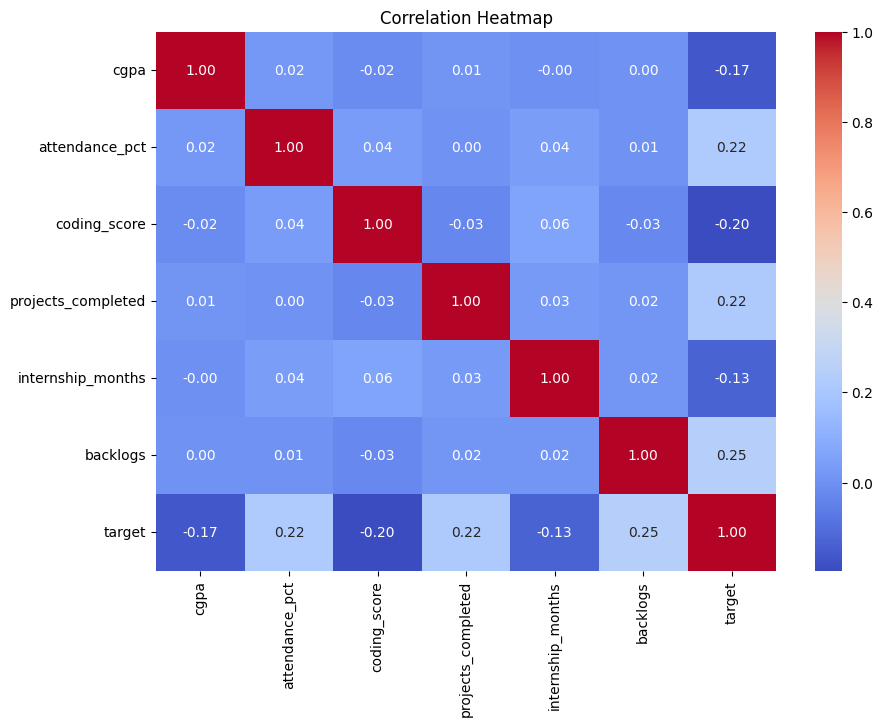

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
      )

plt.title("Correlation Heatmap")
plt.show()

Separate Input and target

In [ ]:
X = df[
      [
              "cgpa",
              "attendance_pct",
              "coding_score",
              "projects_completed",
              "internship_months",
              "backlogs"
        ]
     ]

y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1000, 6)
y shape: (1000,)


train-test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
      X,
      y,
      test_size=0.20,
      random_state=42,
      stratify=y
   )

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (800, 6)
Testing data: (200, 6)


In [ ]:
test_size=0.20

Logistic Regression with preprocessing

In [ ]:
model = Pipeline([
      ("scaler", StandardScaler()),
          ("logistic_regression", LogisticRegression(
                  max_iter=1000,
                          random_state=42
                              ))
                              ])

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


Predictions

In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Predicted classes:")
print(y_pred[:20])

print("\nPredicted probabilities:")
print(y_prob[:20])

Predicted classes:
[0 0 1 0 1 0 1 1 1 0 1 1 0 0 0 0 0 0 0 0]

Predicted probabilities:
[0.35851187 0.17478396 0.5225551  0.24192788 0.68067256 0.32511349
 0.80341561 0.61330971 0.58831583 0.21850405 0.7202767  0.54304252
 0.39127401 0.44726555 0.48885463 0.30291988 0.30929966 0.11429792
 0.41040582 0.28771475]


required performance metrices

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Performance")
print("-------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)

Model Performance
-------------------------
Accuracy : 0.7
Precision: 0.6886792452830188
Recall   : 0.73
F1-score : 0.7087378640776699
ROC-AUC  : 0.7873999999999999


In [ ]:
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.7000
Precision: 0.6887
Recall   : 0.7300
F1-score : 0.7087
ROC-AUC  : 0.7874


Classification report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.67      0.69       100
           1       0.69      0.73      0.71       100

    accuracy                           0.70       200
   macro avg       0.70      0.70      0.70       200
weighted avg       0.70      0.70      0.70       200



Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[67 33]
 [27 73]]


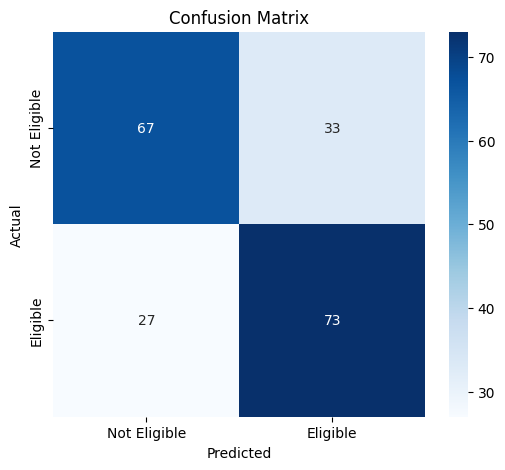

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Eligible", "Eligible"],
    yticklabels=["Not Eligible", "Eligible"]
 )

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

ROC Curve

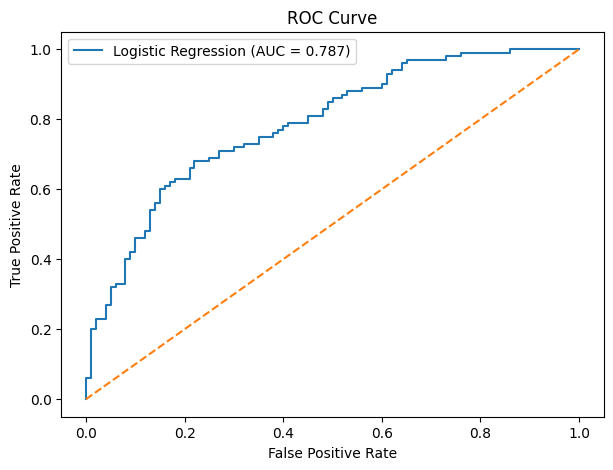

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Feature/Coefficient Interpretation

In [ ]:
logistic_model = model.named_steps["logistic_regression"]

coefficients = logistic_model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
        })

coef_df["Absolute_Coefficient"] = abs(coef_df["Coefficient"])

coef_df = coef_df.sort_values(
     by="Absolute_Coefficient",
     ascending=False
                )

print(coef_df)

              Feature  Coefficient  Absolute_Coefficient
5            backlogs     0.618049              0.618049
1      attendance_pct     0.556093              0.556093
3  projects_completed     0.551368              0.551368
2        coding_score    -0.517072              0.517072
0                cgpa    -0.462246              0.462246
4   internship_months    -0.395385              0.395385


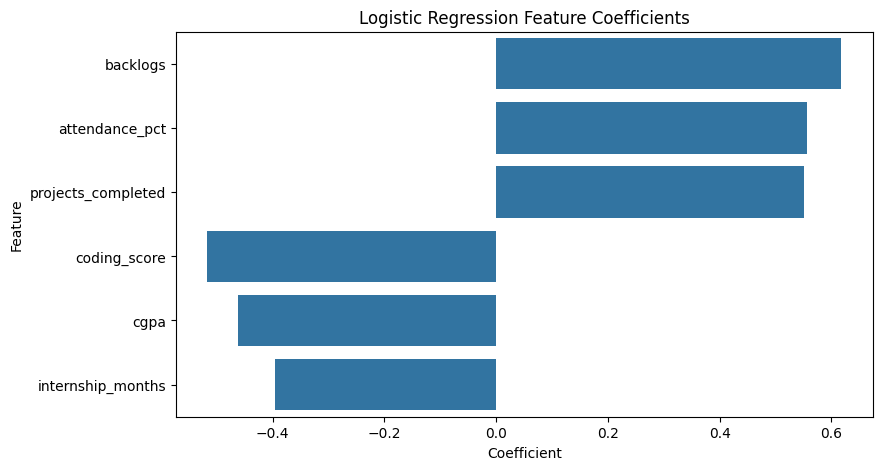

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=coef_df
  )

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

Actual vs predicted

In [ ]:
results = pd.DataFrame({
      "Actual": y_test.values,
       "Predicted": y_pred,
       "Probability": y_prob
 })

print(results.head(20))


    Actual  Predicted  Probability
0        1          0     0.358512
1        0          0     0.174784
2        0          1     0.522555
3        0          0     0.241928
4        1          1     0.680673
5        1          0     0.325113
6        1          1     0.803416
7        1          1     0.613310
8        0          1     0.588316
9        0          0     0.218504
10       1          1     0.720277
11       1          1     0.543043
12       1          0     0.391274
13       0          0     0.447266
14       0          0     0.488855
15       0          0     0.302920
16       1          0     0.309300
17       0          0     0.114298
18       1          0     0.410406
19       0          0     0.287715
